In [17]:
import pickle
with open("val_embeddings_insightface.pkl", "rb") as f:
    extracted = pickle.load(f)

In [2]:
from datasets import load_from_disk
ds = load_from_disk("celeba_faceid_embeddings")
import torch
embeddings = {}
for sample in ds:
    img_name = sample["image_name"]
    embedding = sample["embedding"]
    if embedding is not None:
        embeddings[img_name] = embedding[0]

In [18]:
idx = 3
name = extracted["filenames"][idx]
extracted_embedding = extracted["embeddings"][idx]

In [ ]:
import cv2
from insightface.app import FaceAnalysis
import torch

app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(160, 160))

image = cv2.imread(name)
faces = app.get(image)


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/user/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], w

In [30]:
faceid_embeds = faces[0].normed_embedding

In [ ]:
torch.nn.functional.cosine_similarity(torch.tensor(extracted_embedding)[None], torch.tensor(faceid_embeds)[None])

tensor([0.8153])

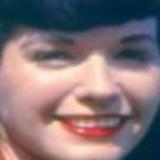

In [49]:
Image.open(extracted["filenames"][2])

In [ ]:
# "photo of a person in library, facing the camera, high quality, 8k resolution, masterpiece" need this prompt

In [1]:
import requests
from io import BytesIO


def compare_faces(img1, img2, api_key, api_secret):
    buf1 = BytesIO()
    img1.save(buf1, format="JPEG")
    buf1.seek(0)

    buf2 = BytesIO()
    img2.save(buf2, format="JPEG")
    buf2.seek(0)

    files = {
        "image_file1": ("img1.jpg", buf1, "image/jpeg"),
        "image_file2": ("img2.jpg", buf2, "image/jpeg")
    }

    data = {
        "api_key": api_key,
        "api_secret": api_secret
    }

    r = requests.post(
        "https://api-us.faceplusplus.com/facepp/v3/compare",
        data=data,
        files=files
    )
    return r.json()

count = 0
success = 0
def add_and_compare(sample):
    global count, success
    filename = sample["filename"]
    generated_image = sample["image"]
    original_image = Image.open(filename)
    result = compare_faces(original_image, generated_image, "YOUR_FACEPP_API_KEY", "YOUR_FACEPP_API_SECRET")
    print(result)
    try:
        face_rectangle = result["faces2"][0]["face_rectangle"]
        face_rectangle = (
            face_rectangle["top"],
            face_rectangle["left"],
            face_rectangle["width"],
            face_rectangle["height"]
        )
        cropped_generated = generated_image.crop((
            face_rectangle[1],
            face_rectangle[0],
            face_rectangle[1] + face_rectangle[2],
            face_rectangle[0] + face_rectangle[3]
        ))
        sample["cropped_generated"] = cropped_generated
        sample["conf"] = result["confidence"]
        if result["confidence"] > result['thresholds']['1e-5']:
            sample["result"] = "1e-5"
        elif result["confidence"] > result['thresholds']['1e-4']:
            sample["result"] = "1e-4"
        elif result["confidence"] > result['thresholds']['1e-3']:
            sample["result"] = "1e-3"
        else:
            sample["result"] = "Above 1e-3"
    except Exception as e:
        sample["conf"] = 0.0
        sample["result"] = "no face detected"
        print(f"Error processing {filename}: {e}")
    count += 1
    if sample["result"] != "no face detected" and sample["conf"] > result['thresholds']['1e-3']:
        success += 1
    print(sample["result"])
    print(f"Success rate: {success}/{count} = {success/count:.2%}")
    sample["original_image"] = Image.open(filename)

    return sample

In [2]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("weathon/fracface", split="train")

In [3]:
from PIL import Image
ds = ds.map(add_and_compare)

In [4]:
ds

Dataset({
    features: ['filename', 'image', 'conf', 'result', 'original_image'],
    num_rows: 507
})

In [5]:
ds.push_to_hub("weathon/fracface")

Uploading the dataset shards:   0%|          | 0/2 [00:00<?, ? shards/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Map:   0%|          | 0/253 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/weathon/fracface/commit/598ec39db06f5c642a5104631e29e93d607d6335', commit_message='Upload dataset', commit_description='', oid='598ec39db06f5c642a5104631e29e93d607d6335', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/weathon/fracface', endpoint='https://huggingface.co', repo_type='dataset', repo_id='weathon/fracface'), pr_revision=None, pr_num=None)

In [6]:
ds

Dataset({
    features: ['filename', 'image', 'conf', 'result', 'original_image'],
    num_rows: 507
})

In [8]:
import numpy as np
val, count = np.unique(ds["result"], return_counts=True)
val = [str(i) for i in val]
res = dict(zip(val, count))
res["Above 1e-3"] += res.pop("no face detected", 0)

In [10]:
import pandas as pd
table = {}
table["Success Rate"] = [res["1e-5"]/count.sum(), res["1e-4"]/count.sum(), res["1e-3"]/count.sum(), res["Above 1e-3"]/count.sum()]
table["Cumulative Success Rate"] = [res["1e-5"]/count.sum(),
                                   (res["1e-5"] + res["1e-4"])/count.sum(),
                                   (res["1e-5"] + res["1e-4"] + res["1e-3"])/count.sum(),
                                   1.0]
df = pd.DataFrame(table, index=["1e-5", "1e-4", "1e-3", "Above 1e-3"])
df

,Success Rate,Cumulative Success Rate
1e-5,0.483235,0.483235
1e-4,0.120316,0.603550
1e-3,0.163708,0.767258
Above 1e-3,0.232742,1.000000


In [ ]:
df = pd.DataFrame(table, index=["1e-5", "1e-4", "1e-3", "below 1e-3"])
df  

,Success Rate,Cumulative Success Rate
1e-5,0.773913,0.773913
1e-4,0.078261,0.852174
1e-3,0.069565,0.921739
below 1e-3,0.078261,1.000000
